In [7]:
from datasets.dem_dataset import DEMTilesDataset

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_normalized.npz"
mask_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/Mounds_raster_mask_opened_closed.npy"

# Create dataset
dataset = DEMTilesDataset(
    dem_path=dem_path,
    mask_path=mask_path,
    tile_size=16,
    stride=8
)


Dataset: 2539389 tiles


In [2]:
print("Кол-во тайлов:", len(dataset))

Кол-во тайлов: 635751


In [20]:
import torch
import numpy as np
for i in range(0, 9000):
    sample = dataset[i]
    img, mask = sample["dem"], sample["mask"]
    if np.unique(mask).size > 1:
        print("Tile: ", i)
        print("Position: ", sample["coords"])
        print("image:", img.shape, img.dtype)   # ожидаем (3, T, T), float32
        print("mask:", mask.shape, mask.dtype)  # ожидаем (T, T), int64
        print("image min/max:", img[img!=-1].min().item(), img[img!=-1].max().item())
        print("mask unique:", np.unique(mask[mask!=-1]))
        break

Tile:  632
Position:  [  24 4472]
image: torch.Size([3, 16, 16]) torch.float32
mask: torch.Size([16, 16]) torch.int64
image min/max: 0.09738525748252869 0.1009979099035263
mask unique: [0 1]


In [4]:
import numpy as np

data = np.load(dem_path)
dem = data["dem"]
valid = data["valid"].astype(bool)

if mask_path.endswith(".npz"):
    mnpz = np.load(mask_path)
    # замените ключ на актуальный, если иной
    labels_arr = mnpz.get("labels_combined", mnpz.get("labels"))
else:
    labels_arr = np.load(mask_path)

print("DEM shape:", dem.shape)
print("VALID shape:", valid.shape)
print("MASK shape:", labels_arr.shape)
assert dem.shape == valid.shape == labels_arr.shape, "Размеры DEM/valid/mask должны совпадать"

DEM shape: (17092, 9791)
VALID shape: (17092, 9791)
MASK shape: (17092, 9791)


In [21]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)  # начните с 0, чтобы проще дебажить
batch = next(iter(loader))
imgs, masks = batch["dem"].float(), batch["valid"].bool()
print("batch image:", imgs.shape, imgs.dtype)  # (B, 3, T, T)
print("batch mask:", masks.shape, masks.dtype) # (B, T, T)
print("mask unique in batch:", torch.unique(masks))

batch image: torch.Size([4, 3, 16, 16]) torch.float32
batch mask: torch.Size([4, 16, 16]) torch.bool
mask unique in batch: tensor([False,  True])


0


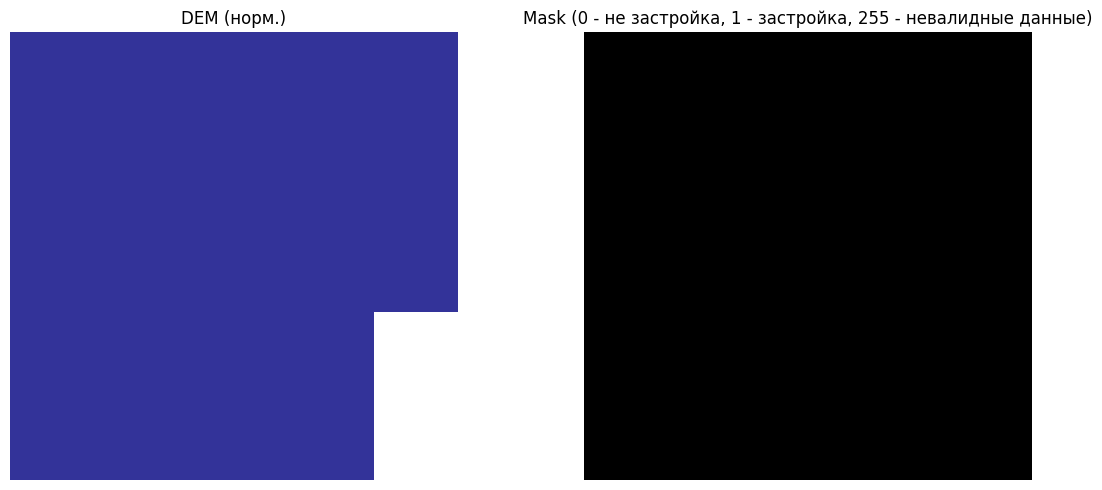

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

k = 0
s = dataset[k]
img = s["dem"].numpy()  # (3, T, T)
mask = s["mask"].numpy()  # (T, T)
print(np.count_nonzero(mask == 1))

# Настраиваем списки цветов для каждого класса
# В данном случае 0 - не застройка, 1 - застройка, 255 - невалидные данные
colors = ['black', 'red', 'gray']
cmap = ListedColormap(colors[:len(np.unique(mask))])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img[0], cmap="terrain")  # один канал
plt.title("DEM (норм.)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap=cmap)
plt.title("Mask (0 - не застройка, 1 - застройка, 255 - невалидные данные)")
plt.axis("off")
plt.tight_layout()
plt.show()

Размер: (16, 16)
Классы в маске: [0 1]
Отсутствующие значения: 240
Кол-во пикселей класса 1: 31


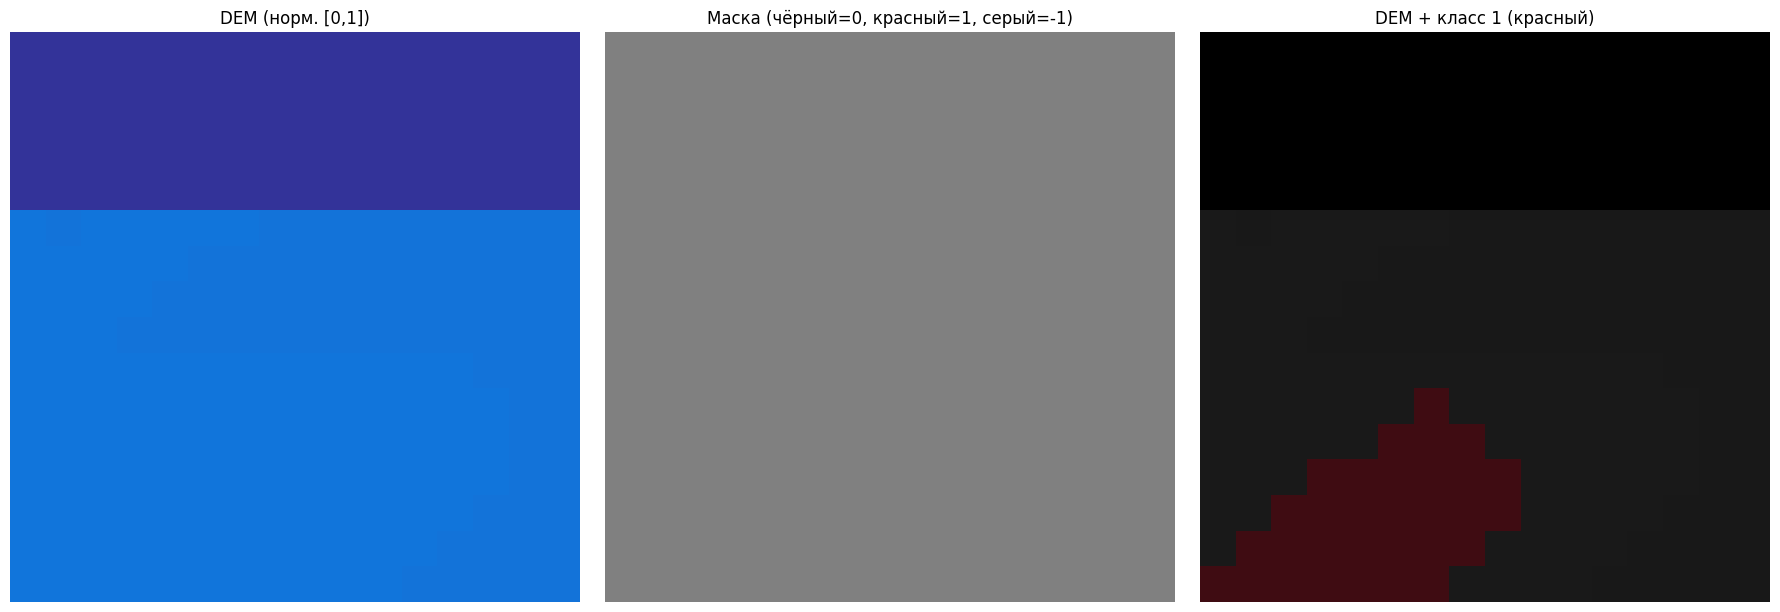

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def plot_sample(img, mask, alpha=0.5):
    """Визуализация DEM и маски с подкраской классов.
    
    Args:
        img: (3, H, W) - изображение DEM
        mask: (H, W) - маска с 0, 1, 255
        alpha: прозрачность наложения маски
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Только DEM
    ax1.imshow(img[0], cmap="terrain", vmin=0, vmax=1)
    ax1.set_title("DEM (норм. [0,1])")
    ax1.axis("off")
    
    # 2. Только маска
    cmap_mask = mcolors.ListedColormap(['black', 'red', 'gray'])
    bounds = [-1, 0, 1]
    norm = mcolors.BoundaryNorm(bounds, cmap_mask.N)
    im = ax2.imshow(mask, cmap=cmap_mask, norm=norm)
    ax2.set_title("Маска (чёрный=0, красный=1, серый=-1)")
    ax2.axis("off")
    
    # 3. DEM + маска (только класс 1)
    ax3.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    mask_vis = np.ma.masked_where(mask != 1, mask)
    ax3.imshow(mask_vis, cmap="Reds", alpha=alpha, vmin=0, vmax=1)
    ax3.set_title("DEM + класс 1 (красный)")
    ax3.axis("off")
    
    plt.tight_layout()
    plt.show()

# Пример использования
k = 633
s = dataset[k]
img = s["dem"].numpy()  # (3, T, T)
mask = s["mask"].numpy()  # (T, T)

print(f"Размер: {mask.shape}")
print(f"Классы в маске: {np.unique(mask)}")
print(f"Отсутствующие значения: {np.count_nonzero(img == -1)}")
print(f"Кол-во пикселей класса 1: {np.count_nonzero(mask == 1)}")

plot_sample(img, mask)

In [31]:
gj = dataset[633]["mask"].numpy()
print(1 not in np.unique(gj))

False


In [33]:
import numpy as np
from collections import Counter

def class_stats(ds, sample_tiles=1000):
    cnt = Counter()
    to_check = min(sample_tiles, len(ds))
    for i in range(to_check):
        tile = ds[i]["mask"].numpy()
        if 1 not in np.unique(tile):
            continue
        vals, freqs = np.unique(tile[tile != -1], return_counts=True)
        for v, f in zip(vals, freqs):
            cnt[int(v)] += int(f)
    
    percents = {k: round(v / sum(cnt.values()), 7) for k, v in cnt.items()}
    return cnt, percents

print("Class balance (примерно):", class_stats(dataset, sample_tiles=len(dataset)))

KeyboardInterrupt: 

In [9]:
from torch.utils.data import Subset, DataLoader

# Get the total number of samples
n_samples = len(dataset)  # Use len(dataset) instead of dataset.dem.shape[0]

# Calculate split indices
train_end = int(n_samples * 0.7)
val_end = train_end + int(n_samples * 0.15)

# Create index lists (not using coords directly)
all_indices = list(range(n_samples))  # [0, 1, 2, ..., n_samples-1]

# Split indices
train_indices = all_indices[:train_end]
val_indices = all_indices[train_end:val_end]
test_indices = all_indices[val_end:]

# Create subsets
train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)
test_subset = Subset(dataset, test_indices)

# Verify the splits
print(f"Total samples: {n_samples}")
print(f"Train samples: {len(train_subset)} ({(len(train_subset)/n_samples):.1%})")
print(f"Val samples: {len(val_subset)} ({(len(val_subset)/n_samples):.1%})")
print(f"Test samples: {len(test_subset)} ({(len(test_subset)/n_samples):.1%})")

# Optional: Verify the first few samples to ensure no data leakage
print("\nFirst few train samples:")
for i in range(min(3, len(train_subset))):
    sample = train_subset[i]
    print(f"  Sample {i}: coords={sample['coords']}")

print("\nFirst few val samples:")
for i in range(min(3, len(val_subset))):
    sample = val_subset[i]
    print(f"  Sample {i}: coords={sample['coords']}")
    
print("\nFirst few test samples:")
for i in range(min(3, len(test_subset))):
    sample = test_subset[i]
    print(f"  Sample {i}: coords={sample['coords']}")


Total samples: 2539389
Train samples: 1777572 (70.0%)
Val samples: 380908 (15.0%)
Test samples: 380909 (15.0%)

First few train samples:
  Sample 0: coords=[   0 8064]
  Sample 1: coords=[   0 8072]
  Sample 2: coords=[   0 8080]

First few val samples:
  Sample 0: coords=[11912  3000]
  Sample 1: coords=[11912  3008]
  Sample 2: coords=[11912  3016]

First few test samples:
  Sample 0: coords=[14472  2432]
  Sample 1: coords=[14472  2440]
  Sample 2: coords=[14472  2448]


In [34]:
train_dataloader = DataLoader(train_subset, batch_size=4, num_workers=4, shuffle=True)
val_dataloader = DataLoader(val_subset, batch_size=4, num_workers=4, shuffle=False)
test_dataloader = DataLoader(test_subset, batch_size=4, num_workers=4, shuffle=False)

# вставьте в training loop или отдельный скрипт — один батч
batch = next(iter(train_dataloader))
masks = batch['mask']  # tensor
print('mask dtype:', masks.dtype)
print('mask min/max/unique (sample):', masks.min().item(), masks.max().item(), torch.unique(masks)[:20])

mask dtype: torch.int64
mask min/max/unique (sample): 0 0 tensor([0])


In [39]:
from torch.utils.data import Subset, DataLoader

# Получаем все координаты
coords = np.array(dataset.coords)  # shape: (N, 2) -> [y, x]

# Разделим по оси Y (например, верх 70%, низ 30%)
y_values = coords[:, 0]
y_threshold = np.percentile(y_values, 70)

train_indices = [i for i, (y, _) in enumerate(dataset.coords) if y < y_threshold]
val_indices   = [i for i, (y, _) in enumerate(dataset.coords) if y >= y_threshold]
#test_indices  = [i for i, (y, _) in enumerate(dataset.coords) if y >= y_threshold]

# Создаём сабсеты
train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)
#test_subset = Subset(dataset, test_indices)

train_dataloader = DataLoader(train_subset, batch_size=4, num_workers=4, shuffle=True)
val_dataloader = DataLoader(val_subset, batch_size=4, num_workers=4, shuffle=False)
test_dataloader = DataLoader(test_subset, batch_size=4, num_workers=4, shuffle=False)

print(f"Train tiles: {len(train_indices)} | Val tiles: {len(val_indices)}") #| Test tiles: {len(test_indices)}")


Train tiles: 1777197 | Val tiles: 762192


In [ ]:
import numpy as np

# target_tiles — список или массив бинарных масок (0/1)
all_masks = np.concatenate([mask for mask in dataset])
num_pos = (all_masks == 1).sum()
num_neg = (all_masks == 0).sum()

pos_weight = num_neg / (num_pos + 1e-8)
print(f"Positive weight: {pos_weight:.2f}")